Let's get the attribution dataset, it is somewhat smaller than the 2023 one

In [1]:
!wget http://go.criteo.net/criteo-research-attribution-dataset.zip -O criteo.zip

--2025-11-17 12:55:58--  http://go.criteo.net/criteo-research-attribution-dataset.zip
Resolving go.criteo.net (go.criteo.net)... 74.119.118.85, 2620:100:a005::25
Connecting to go.criteo.net (go.criteo.net)|74.119.118.85|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://criteostorage.blob.core.windows.net/criteo-research-datasets/criteo_attribution_dataset.zip [following]
--2025-11-17 12:55:59--  https://criteostorage.blob.core.windows.net/criteo-research-datasets/criteo_attribution_dataset.zip
Resolving criteostorage.blob.core.windows.net (criteostorage.blob.core.windows.net)... 20.209.1.1
Connecting to criteostorage.blob.core.windows.net (criteostorage.blob.core.windows.net)|20.209.1.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 653128946 (623M) [application/zip]
Saving to: ‘criteo.zip’

criteo.zip          100%[===================>] 622.87M  11.6MB/s    in 54s     

2025-11-17 12:56:53 (11.6 MB/s) - ‘criteo.zip’ saved 

In [2]:
!unzip criteo.zip -d criteo_data

Archive:  criteo.zip
  inflating: criteo_data/Experiments.ipynb  
  inflating: criteo_data/README.md   
  inflating: criteo_data/criteo_attribution_dataset.tsv.gz  


There are 16.5 million impressions/rows can't just read it as it is

Additional reading on duckdb to be done later

In [40]:
import duckdb

con = duckdb.connect()

df = con.execute("""
    SELECT *
    FROM read_csv_auto(
        '/content/criteo_data/criteo_attribution_dataset.tsv.gz',
        delim='\t'
    )
    LIMIT 50000
""").df()

df.head()

,timestamp,uid,campaign,conversion,conversion_timestamp,conversion_id,attribution,click,click_pos,click_nb,...,time_since_last_click,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9
0,0,20073966,22589171,0,-1,-1,0,0,-1,-1,...,-1,5824233,9312274,3490278,29196072,11409686,1973606,25162884,29196072,29196072
1,2,24607497,884761,0,-1,-1,0,0,-1,-1,...,423858,30763035,9312274,14584482,29196072,11409686,1973606,22644417,9312274,21091111
2,2,28474333,18975823,0,-1,-1,0,0,-1,-1,...,8879,138937,9312274,10769841,29196072,5824237,138937,1795451,29196072,15351056
3,3,7306395,29427842,1,1449193,3063962,0,1,0,7,...,-1,28928366,26597095,12435261,23549932,5824237,1973606,9180723,29841067,29196072
4,3,25357769,13365547,0,-1,-1,0,0,-1,-1,...,-1,138937,26597094,31616034,29196072,11409684,26597096,4480345,29196072,29196072


Let's reproduce some of authors feature engineering

In [41]:
import numpy as np

# EDA

In [42]:
print(df['campaign'].nunique())
print(df['cat1'].nunique())
print(df['click'].mean())


637
9
0.36482


In [44]:
df['day'] = np.floor(df.timestamp / 86400.).astype(int)

In [43]:
df['hour'] = ((df.timestamp % 86400) // 3600).astype(int)

In [46]:
drop_cols = [
    'uid', 'conversion_id', 'conversion_timestamp',
    'conversion', 'attribution', 'cpo',  # only drop for CTR stage, whether conversion happened, and if its attributed to criteo is a different ballgame,
    'timestamp'
]
df = df.drop(columns=drop_cols)

In [47]:
df.columns

Index(['campaign', 'click', 'click_pos', 'click_nb', 'cost',
       'time_since_last_click', 'cat1', 'cat2', 'cat3', 'cat4', 'cat5', 'cat6',
       'cat7', 'cat8', 'cat9', 'hour', 'day'],
      dtype='object')

In [48]:
cat_features = ['campaign',
                'cat1','cat2','cat3','cat4','cat5','cat6','cat7','cat8','cat9']

for c in cat_features:
    df[c] = df[c].astype(str)
# lightgbm handles categorical values only if passsed as strings

In [49]:
FEATURES = [
    'campaign',
    'cat1','cat2','cat3','cat4','cat5','cat6','cat7','cat8','cat9',
    'click_pos', 'click_nb', 'time_since_last_click',
    'day', 'hour'
]

LABEL = 'click'


In [50]:
from sklearn.model_selection import train_test_split

train_df, valid_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

print(len(train_df), len(valid_df))


40000 10000


In [56]:
df.columns

Index(['campaign', 'click', 'click_pos', 'click_nb', 'cost',
       'time_since_last_click', 'cat1', 'cat2', 'cat3', 'cat4', 'cat5', 'cat6',
       'cat7', 'cat8', 'cat9', 'hour', 'day'],
      dtype='object')

In [51]:
train_df.head()

,campaign,click,click_pos,click_nb,cost,time_since_last_click,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,hour,day
39087,7121544,0,-1,-1,0.000144,-1,30763035,26597095,13886764,29196072,32440044,29196072,6153679,29196072,29196072,6,0
30893,6686701,0,-1,-1,0.000072,176727,28928366,26597095,13830208,23549932,32440044,29196072,15013288,29196072,21091108,5,0
45278,8403848,0,-1,-1,0.000054,-1,1973606,5642940,694450,29196072,32440044,28928366,32142928,29196072,29196072,6,0
16398,8980571,0,-1,-1,0.000010,256981,30763035,9312274,9181301,29196072,11409686,1973606,9847387,9312274,21091108,4,0
13653,30427825,0,-1,-1,0.000144,-1,138937,9312274,2644591,29196072,30763035,30763035,14519920,29196072,29196072,3,0


In [52]:
print(train_df['click'].mean(), valid_df['click'].mean())

0.3656 0.3617


In [ ]:
cat_features = [
    'campaign',
    'cat1','cat2','cat3','cat4','cat5','cat6','cat7','cat8','cat9'
]

for c in cat_features:
    train_df[c] = train_df[c].astype('category').cat.codes
    valid_df[c] = valid_df[c].astype('category').cat.codes

strings don't work? convert to pandas category

In [77]:
cat_features = [
    'campaign',
    'cat1','cat2','cat3','cat4','cat5','cat6','cat7','cat8','cat9'
]

for c in cat_features:
    df[c] = df[c].astype('category').cat.codes


In [71]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40000 entries, 39087 to 15795
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   campaign               40000 non-null  int16  
 1   click                  40000 non-null  int64  
 2   click_pos              40000 non-null  int64  
 3   click_nb               40000 non-null  int64  
 4   cost                   40000 non-null  float64
 5   time_since_last_click  40000 non-null  int64  
 6   cat1                   40000 non-null  int8   
 7   cat2                   40000 non-null  int8   
 8   cat3                   40000 non-null  int16  
 9   cat4                   40000 non-null  int8   
 10  cat5                   40000 non-null  int8   
 11  cat6                   40000 non-null  int8   
 12  cat7                   40000 non-null  int16  
 13  cat8                   40000 non-null  int8   
 14  cat9                   40000 non-null  int8   
 15  hou

In [72]:
df.head()

,campaign,click,click_pos,click_nb,cost,time_since_last_click,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,hour,day
0,241,0,-1,-1,0.000010,-1,7,51,1037,10,2,2,2861,4,15,0,0
1,606,0,-1,-1,0.000010,423858,5,51,208,10,2,2,2417,10,9,0,0
2,191,0,-1,-1,0.000183,8879,0,51,27,10,43,0,1557,4,1,0,0
3,398,1,0,7,0.000094,-1,4,14,103,7,43,2,5261,5,15,0,0
4,68,0,-1,-1,0.000032,-1,0,13,984,10,0,8,4374,4,15,0,0


In [82]:
import matplotlib.pyplot as plt
import seaborn as sb

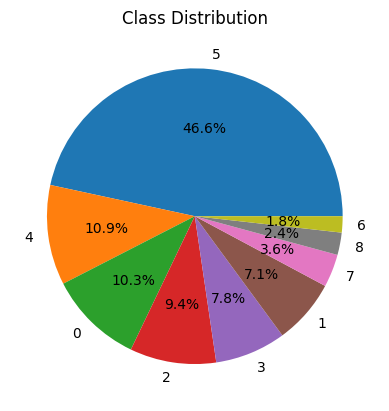

In [76]:
temp = train_df['cat1'].value_counts()
plt.pie(temp.values, labels=temp.index.values, autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

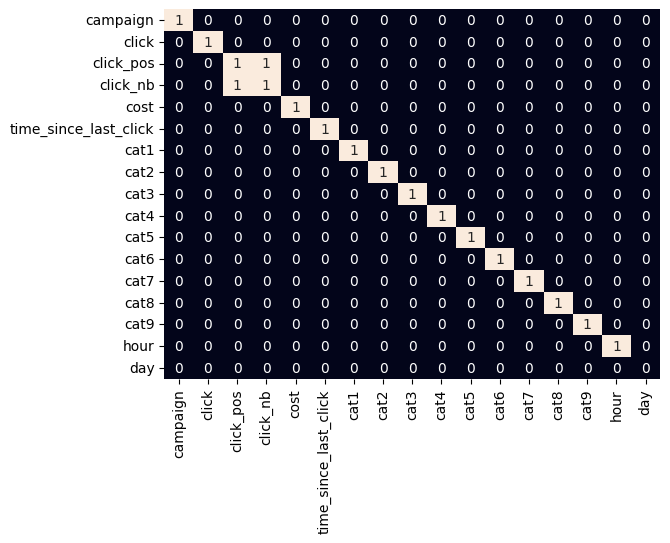

In [83]:
sb.heatmap(df.corr() > 0.7, cbar=False, annot=True)
plt.show()

In [84]:
train_df.columns

Index(['campaign', 'click', 'click_pos', 'click_nb', 'cost',
       'time_since_last_click', 'cat1', 'cat2', 'cat3', 'cat4', 'cat5', 'cat6',
       'cat7', 'cat8', 'cat9', 'hour', 'day'],
      dtype='object')

In [85]:
import lightgbm as lgb

lgb_train = lgb.Dataset(
    train_df[FEATURES],
    label=train_df[LABEL]
)

lgb_valid = lgb.Dataset(
    valid_df[FEATURES],
    label=valid_df[LABEL]
)


In [86]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 48,
    'verbose': 1
}

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=100,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=['train','valid']
)


[LightGBM] [Info] Number of positive: 14624, number of negative: 25376
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002177 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1273
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.365600 -> initscore=-0.551140
[LightGBM] [Info] Start training from score -0.551140


In [87]:
model.save_model("pctr_baseline.txt")

In [88]:
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score

# Predictions
train_pred = model.predict(train_df[FEATURES])
valid_pred = model.predict(valid_df[FEATURES])

# Metrics
train_auc = roc_auc_score(train_df[LABEL], train_pred)
valid_auc = roc_auc_score(valid_df[LABEL], valid_pred)

train_logloss = log_loss(train_df[LABEL], train_pred)
valid_logloss = log_loss(valid_df[LABEL], valid_pred)

# For accuracy, threshold = 0.5 (NOT important for CTR but okay to check)
train_acc = accuracy_score(train_df[LABEL], train_pred > 0.5)
valid_acc = accuracy_score(valid_df[LABEL], valid_pred > 0.5)

print("Train AUC:", train_auc)
print("Valid AUC:", valid_auc)
print("Train Logloss:", train_logloss)
print("Valid Logloss:", valid_logloss)
print("Train Acc:", train_acc)
print("Valid Acc:", valid_acc)


Train AUC: 0.7715517236733272
Valid AUC: 0.6955089312913055
Train Logloss: 0.5351200991980827
Valid Logloss: 0.5719924965250759
Train Acc: 0.72435
Valid Acc: 0.7035


In [89]:
df['pCTR'] = model.predict(df[FEATURES])

In [90]:
df.head()

,campaign,click,click_pos,click_nb,cost,time_since_last_click,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,hour,day,pCTR
0,241,0,-1,-1,0.000010,-1,7,51,1037,10,2,2,2861,4,15,0,0,0.248305
1,606,0,-1,-1,0.000010,423858,5,51,208,10,2,2,2417,10,9,0,0,0.219405
2,191,0,-1,-1,0.000183,8879,0,51,27,10,43,0,1557,4,1,0,0,0.391956
3,398,1,0,7,0.000094,-1,4,14,103,7,43,2,5261,5,15,0,0,0.995833
4,68,0,-1,-1,0.000032,-1,0,13,984,10,0,8,4374,4,15,0,0,0.470075


In [91]:
def plot_avg_pctr(feature):
    plt.figure(figsize=(10,5))
    df.groupby(feature)["pCTR"].mean().plot(kind="bar")
    plt.xlabel(feature)
    plt.ylabel("Average pCTR")
    plt.title(f"{feature} vs Average pCTR")
    plt.tight_layout()
    plt.show()


never mind there are lots of campaigns

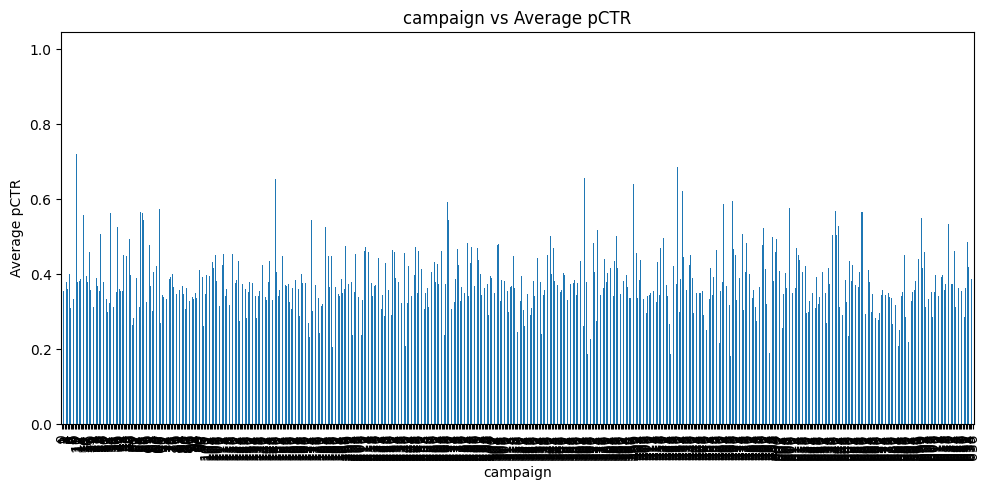

In [92]:
plot_avg_pctr("campaign")

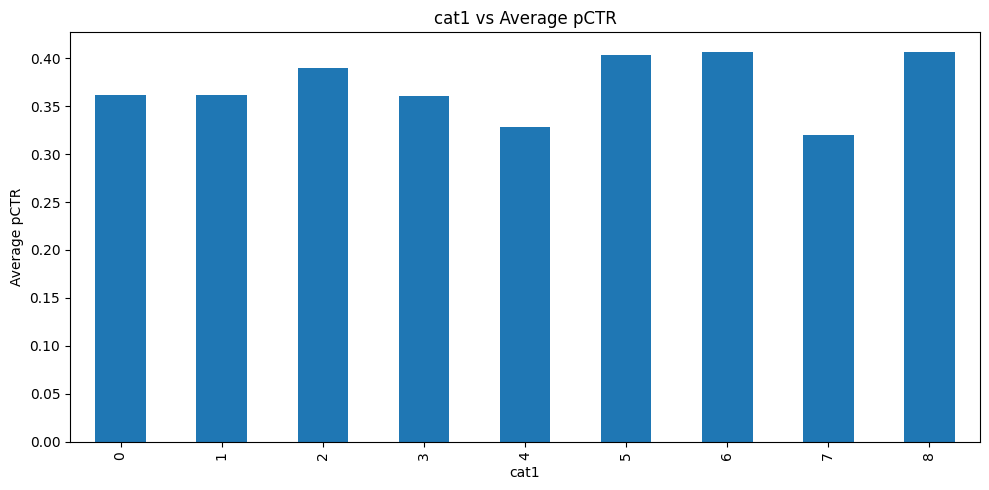

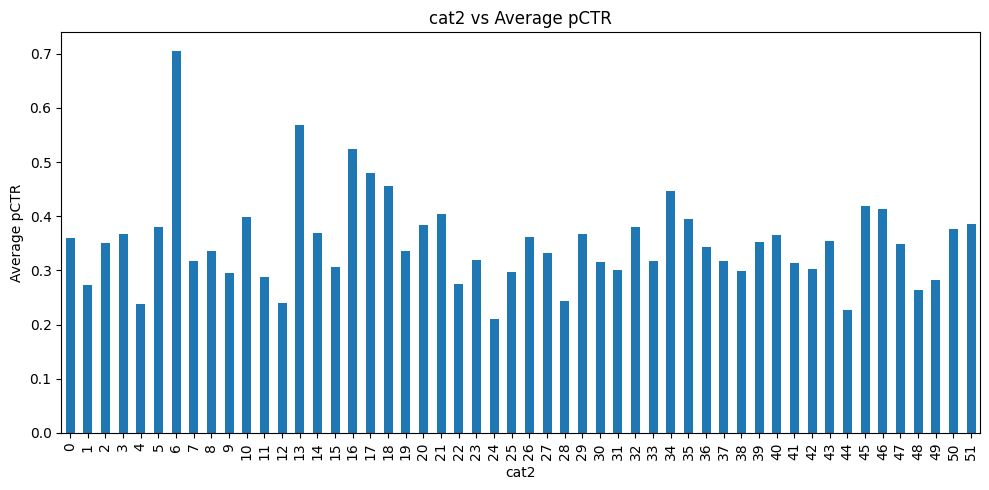

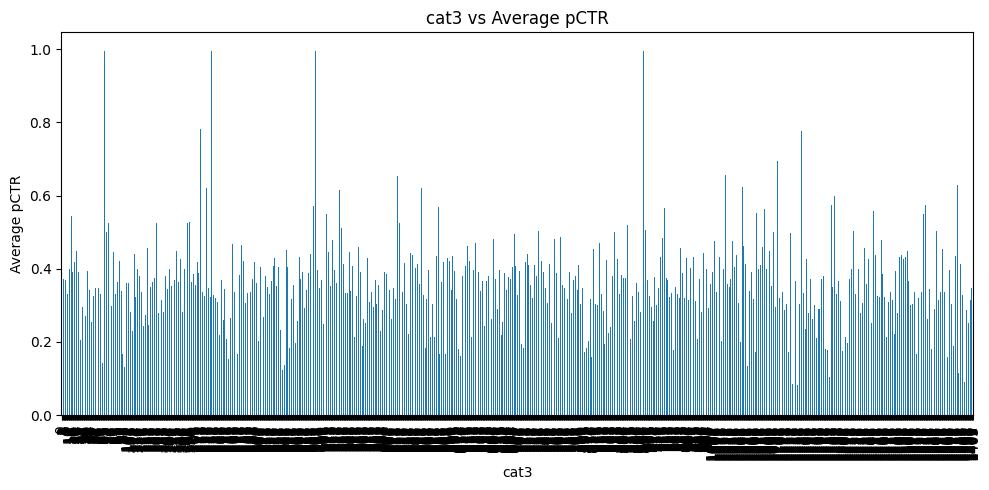

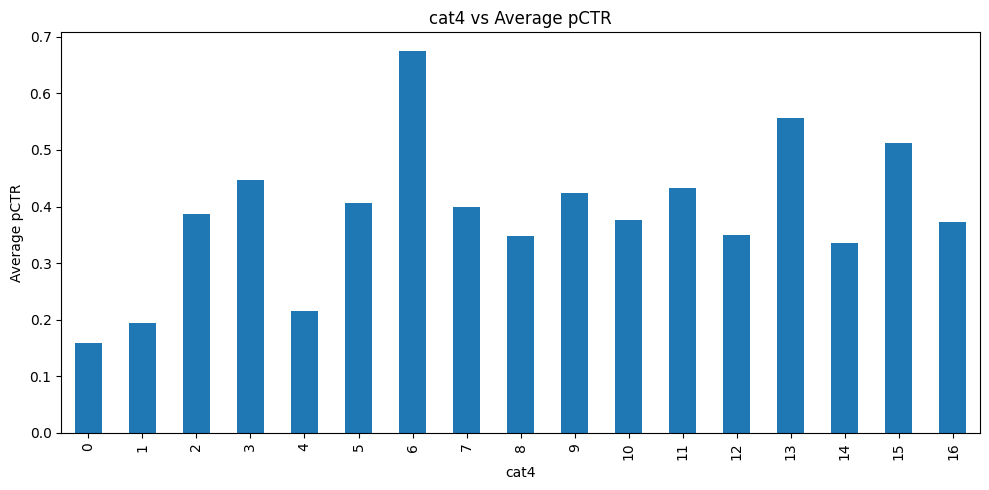

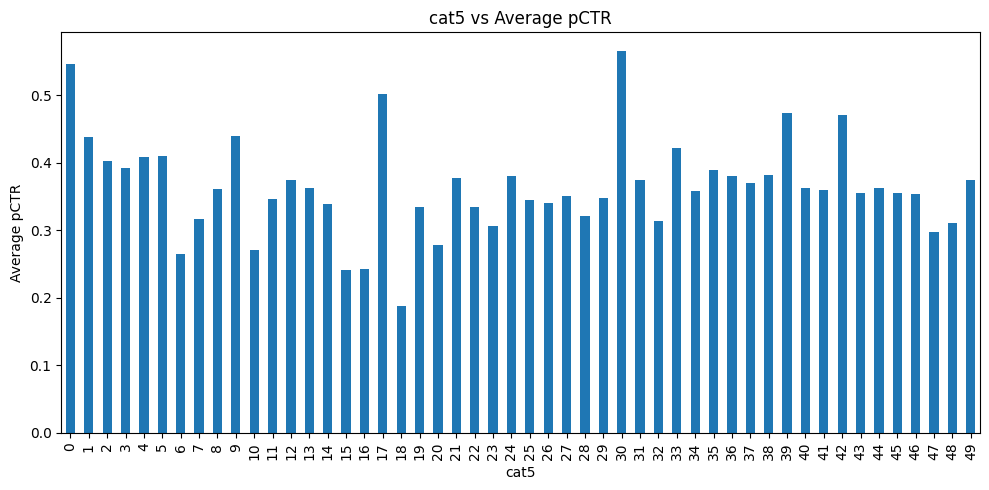

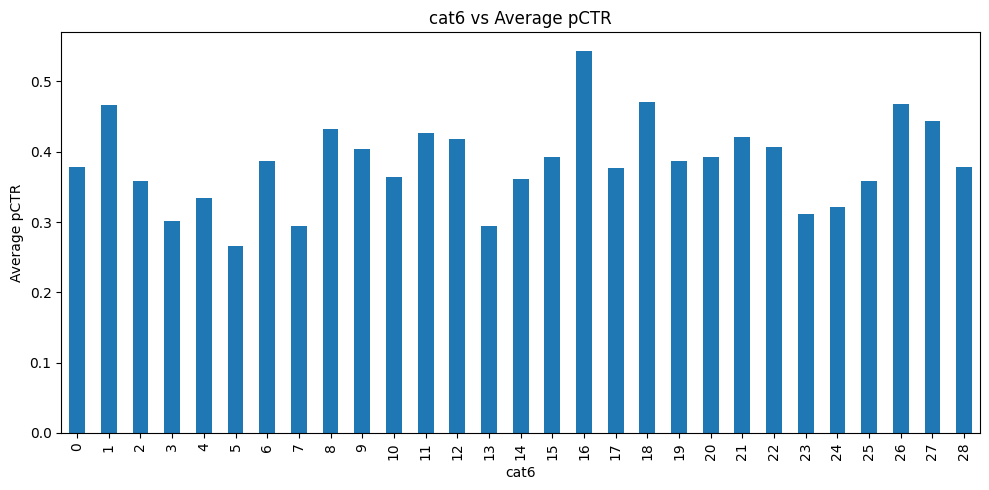

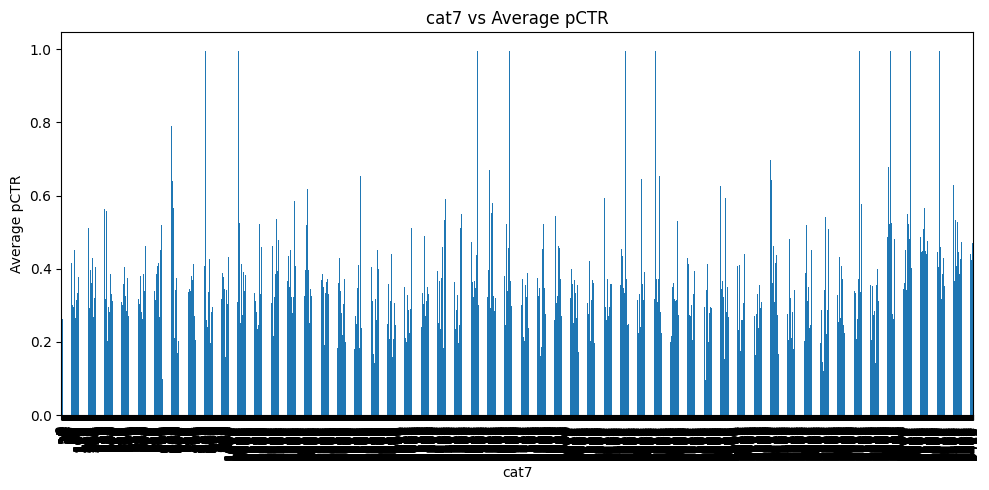

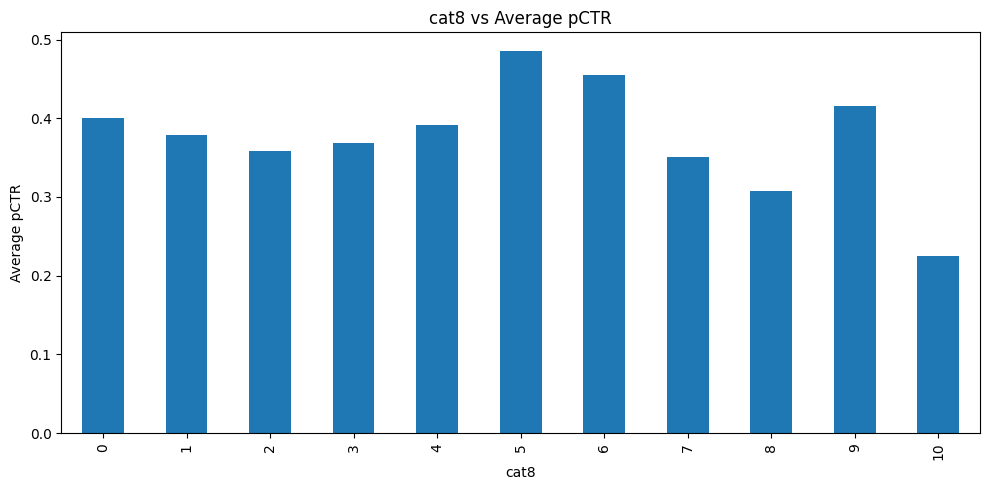

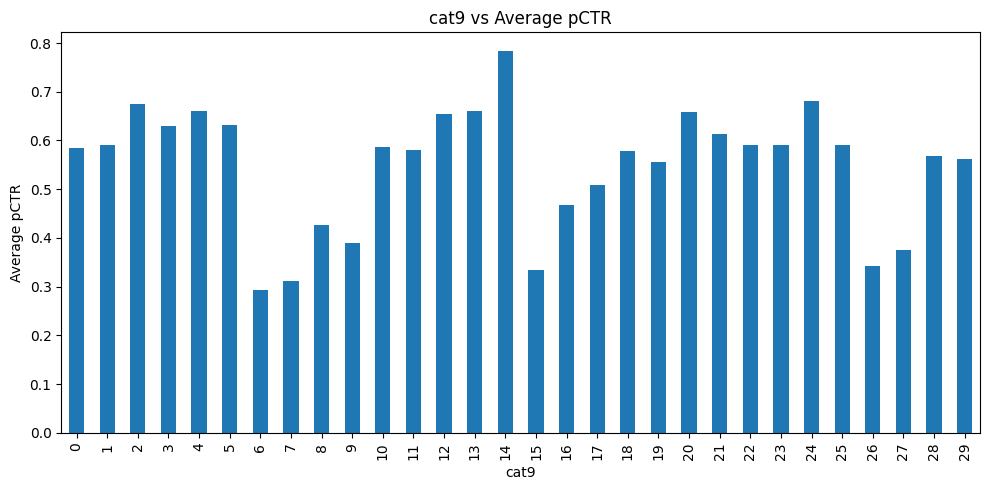

In [93]:
categorical_cols = ["cat1","cat2","cat3","cat4","cat5","cat6","cat7","cat8","cat9"]

for col in categorical_cols:
    plot_avg_pctr(col)


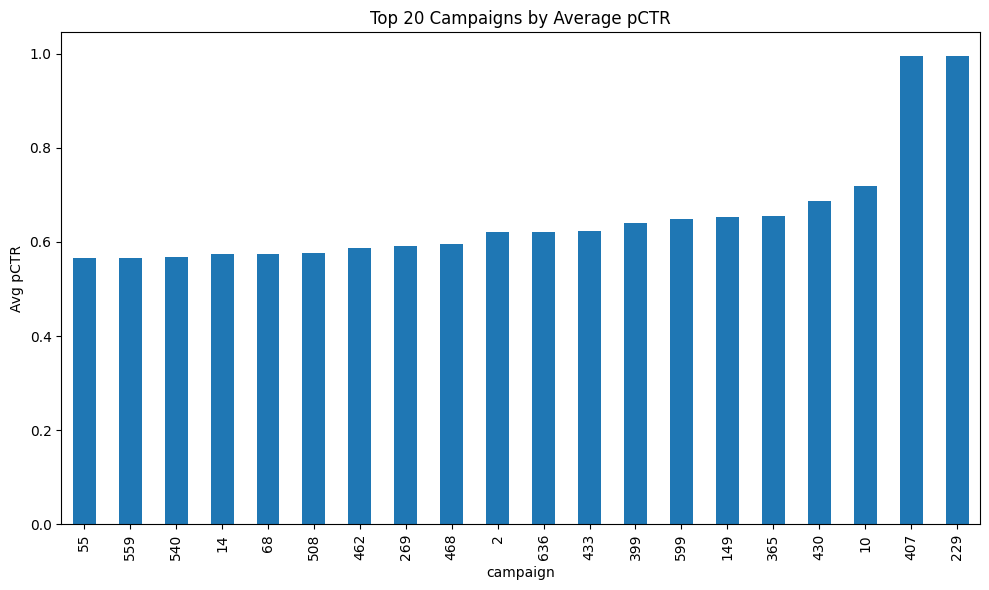

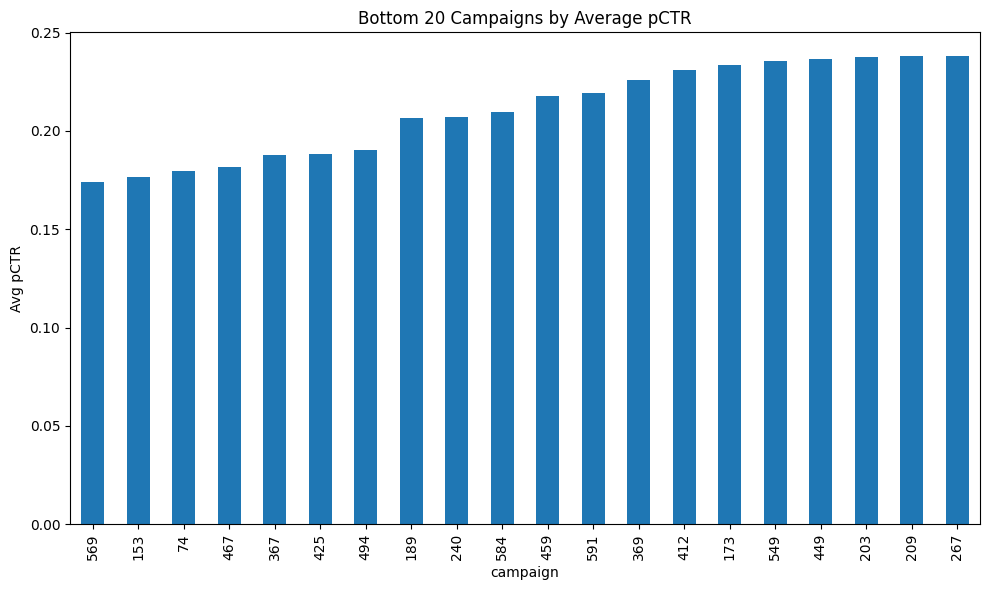

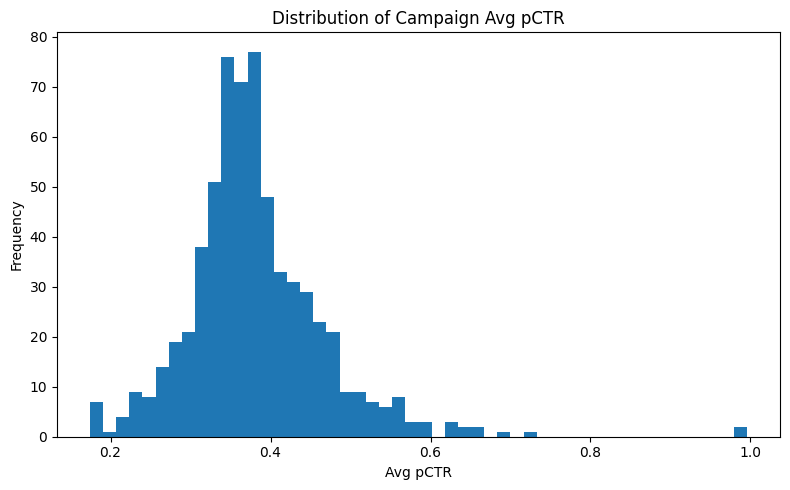

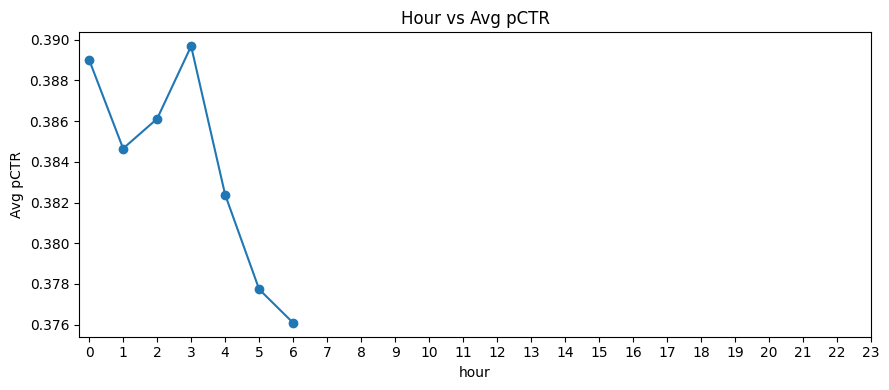

In [97]:
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------
# 1. Top-N campaigns by pCTR
# -----------------------
N = 20  # change if needed
campaign_avg = df.groupby("campaign")["pCTR"].mean().sort_values()

plt.figure(figsize=(10,6))
campaign_avg.tail(N).plot(kind="bar")
plt.title(f"Top {N} Campaigns by Average pCTR")
plt.ylabel("Avg pCTR")
plt.tight_layout()
plt.show()

# -----------------------
# 2. Bottom-N campaigns by pCTR
# -----------------------
plt.figure(figsize=(10,6))
campaign_avg.head(N).plot(kind="bar")
plt.title(f"Bottom {N} Campaigns by Average pCTR")
plt.ylabel("Avg pCTR")
plt.tight_layout()
plt.show()

# -----------------------
# 3. Campaign pCTR distribution (Histogram)
# -----------------------
plt.figure(figsize=(8,5))
plt.hist(campaign_avg, bins=50)
plt.title("Distribution of Campaign Avg pCTR")
plt.xlabel("Avg pCTR")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# -----------------------
# 6. Hour-level summary (small cardinality)
# -----------------------
plt.figure(figsize=(9,4))
df.groupby("hour")["pCTR"].mean().plot(kind="line", marker="o")
plt.title("Hour vs Avg pCTR")
plt.ylabel("Avg pCTR")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

## Model takes these as input, so for any subset of the df, column wise or row wise, as long as these features are present we can augment the dataset with pCTR

In [98]:
FEATURES

['campaign',
 'cat1',
 'cat2',
 'cat3',
 'cat4',
 'cat5',
 'cat6',
 'cat7',
 'cat8',
 'cat9',
 'click_pos',
 'click_nb',
 'time_since_last_click',
 'day',
 'hour']

In [99]:
LABEL

'click'

In [100]:
df.dtypes

,0
campaign,int16
click,int64
click_pos,int64
click_nb,int64
cost,float64
time_since_last_click,int64
cat1,int8
cat2,int8
cat3,int16
cat4,int8


In [101]:
opt_df = df[['campaign', 'cost', 'pCTR', 'click']].copy()

In [102]:
opt_df['pCTR_per_cost'] = opt_df['pCTR'] / opt_df['cost']

In [103]:
opt_df_sorted = opt_df.sort_values('pCTR_per_cost', ascending=False)

In [104]:
df.to_csv("ctr_df_1.csv", index=False)
opt_df_sorted.to_csv("opt_df_1.csv", index=False)

In [105]:
from google.colab import files

files.download("ctr_df_1.csv")
files.download("opt_df_1.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>